# Calculadora de Pension IMSS: Ley 73 vs Ley 97

Este cuaderno compara los resultados de pension para dos trabajadores del IMSS:

- **Trabajador A** -- inscrito antes de julio de 1997, se pensiona bajo **Ley 73** (beneficio definido).
- **Trabajador B** -- inscrito despues de julio de 1997, se pensiona bajo **Ley 97** (contribucion definida via AFORE).

Se exploran los factores que determinan el monto de pension en cada regimen: semanas cotizadas, salario promedio, edad de retiro, saldo de AFORE y modalidad de pago (renta vitalicia vs retiro programado). Tambien se muestra como las funciones de conmutacion alimentan el calculo actuarial de la renta vitalicia.

**Marco regulatorio**: Ley del Seguro Social (Arts. 154-171), CONSAR, tabla de mortalidad EMSSA-09.

In [1]:
import sys
sys.path.insert(0, "../src")

from decimal import Decimal

import matplotlib.pyplot as plt
import pandas as pd

from suite_actuarial.pensiones import (
    PensionLey73,
    PensionLey97,
    CalculadoraIMSS,
    TablaConmutacion,
    RentaVitalicia,
)
from suite_actuarial.actuarial.mortality.tablas import TablaMortalidad
from suite_actuarial.pensiones.tablas_imss import LEY73_FACTORES_EDAD

print("Modulos cargados correctamente.")

Modulos cargados correctamente.


## Caso 1: Trabajador Ley 73

Don Manuel se inscribio al IMSS en 1990, acumulo **1,500 semanas cotizadas** y tiene un salario promedio diario de **$900 MXN** (ultimas 250 semanas). Se retira a los **65 anos**.

Bajo la Ley 73, la pension se calcula como:

$$\text{Pension mensual} = \text{Salario promedio diario} \times 30 \times \text{Porcentaje}(\text{semanas}) \times \text{Factor}(\text{edad})$$

A los 65 anos, el factor de edad es 1.00 (pension completa).

In [2]:
# Crear calculadora Ley 73
pension73 = PensionLey73(
    semanas_cotizadas=1500,
    salario_promedio_5_anos=Decimal("900"),  # salario diario
    edad_retiro=65,
)

# Calcular componentes
pension_mensual = pension73.calcular_pension_mensual()
aguinaldo = pension73.calcular_aguinaldo()
pension_anual = pension73.calcular_pension_anual_total()

# Resumen completo
resumen = pension73.resumen()
print("=" * 55)
print("  PENSION LEY 73 -- Don Manuel")
print("=" * 55)
for k, v in resumen.items():
    if isinstance(v, Decimal):
        print(f"  {k:30s}  ${v:>12,.2f}")
    else:
        print(f"  {k:30s}  {v}")
print("=" * 55)

  PENSION LEY 73 -- Don Manuel
  regimen                         Ley 73
  semanas_cotizadas               1500
  salario_promedio_diario         $      900.00
  edad_retiro                     65
  porcentaje_pension              $        0.77
  factor_edad                     $        1.00
  pension_mensual                 $   20,819.28
  aguinaldo_anual                 $   20,819.28
  pension_anual_total             $  270,650.64


## Efecto de la edad de retiro

En la Ley 73, retirarse antes de los 65 anos implica un factor de reduccion (cesantia en edad avanzada). Veamos como cambia la pension mensual entre los 60 y 65 anos.

 Edad de retiro  Factor de edad Pension mensual ($)
             60            0.75          $15,614.46
             61            0.80          $16,655.43
             62            0.85          $17,696.39
             63            0.90          $18,737.36
             64            0.95          $19,778.32
             65            1.00          $20,819.28


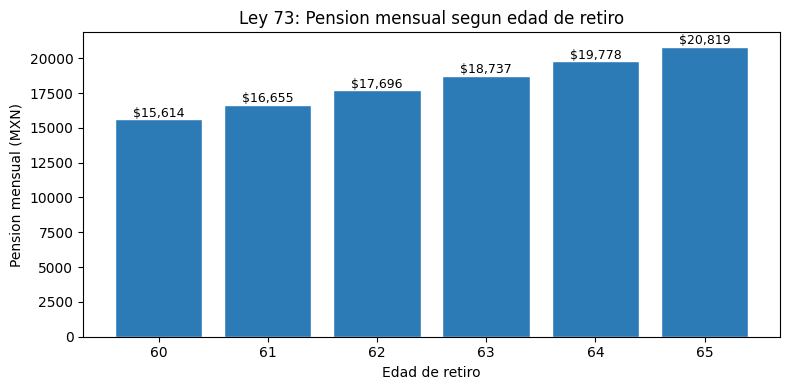

In [3]:
# Pension mensual por edad de retiro (60-65)
edades = list(range(60, 66))
pensiones = []
factores = []

for edad in edades:
    p = PensionLey73(
        semanas_cotizadas=1500,
        salario_promedio_5_anos=Decimal("900"),
        edad_retiro=edad,
    )
    pensiones.append(float(p.calcular_pension_mensual()))
    factores.append(float(LEY73_FACTORES_EDAD[edad]))

df_edad = pd.DataFrame({
    "Edad de retiro": edades,
    "Factor de edad": factores,
    "Pension mensual ($)": [f"${p:,.2f}" for p in pensiones],
})
print(df_edad.to_string(index=False))

# Grafica
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(edades, pensiones, color="#2c7bb6", edgecolor="white")
ax.set_xlabel("Edad de retiro")
ax.set_ylabel("Pension mensual (MXN)")
ax.set_title("Ley 73: Pension mensual segun edad de retiro")
for i, (e, p) in enumerate(zip(edades, pensiones)):
    ax.text(e, p + 200, f"${p:,.0f}", ha="center", fontsize=9)
ax.set_xticks(edades)
plt.tight_layout()
plt.show()

## Caso 2: Trabajador Ley 97

Lucia se inscribio al IMSS en 2005. Tiene 60 anos, 1,100 semanas cotizadas, un saldo de AFORE de **$2,000,000 MXN** y un salario actual de **$25,000/mes**. Proyectaremos su saldo AFORE si se retira en 5 anos mas (a los 65).

In [4]:
# Crear calculadora Ley 97
pension97 = PensionLey97(
    saldo_afore=Decimal("2000000"),
    edad=60,
    sexo="M",  # Mujer
    semanas_cotizadas=1100,
)

# Proyeccion del saldo AFORE a 5 anos
proyeccion = pension97.proyectar_saldo_afore(
    salario_actual=Decimal("25000"),
    rendimiento_anual=Decimal("0.045"),  # 4.5% real
    anos_restantes=5,
)

df_proy = pd.DataFrame(proyeccion)
df_proy["salario_mensual"] = df_proy["salario_mensual"].apply(lambda x: f"${x:,.2f}")
df_proy["aportacion_anual"] = df_proy["aportacion_anual"].apply(lambda x: f"${x:,.2f}")
df_proy["saldo_afore"] = df_proy["saldo_afore"].apply(lambda x: f"${x:,.2f}")

print("Proyeccion del saldo AFORE de Lucia (5 anos)")
print("-" * 70)
print(df_proy.to_string(index=False))

Proyeccion del saldo AFORE de Lucia (5 anos)
----------------------------------------------------------------------
 ano  edad salario_mensual aportacion_anual   saldo_afore
   0    60      $25,000.00            $0.00 $2,000,000.00
   1    61      $26,000.00       $32,325.00 $2,122,325.00
   2    62      $27,040.00       $33,618.00 $2,251,447.62
   3    63      $28,121.60       $34,962.72 $2,387,725.49
   4    64      $29,246.46       $36,361.23 $2,531,534.36
   5    65      $30,416.32       $37,815.68 $2,683,269.09


## Renta vitalicia vs Retiro programado

Al pensionarse bajo Ley 97, el trabajador elige entre dos modalidades:

- **Renta vitalicia**: el saldo AFORE se entrega a una aseguradora que paga una pension mensual garantizada de por vida.
- **Retiro programado**: se retira periodicamente de la AFORE; el monto se recalcula cada ano y puede agotarse.

Comparemos ambas para Lucia con su saldo actual a los 60 anos.

In [5]:
# Comparar modalidades
comparacion = pension97.comparar_modalidades()

print("=" * 60)
print("  COMPARACION DE MODALIDADES -- Lucia (Ley 97)")
print("=" * 60)
print(f"  Saldo AFORE:          ${comparacion['saldo_afore']:>14,.2f}")
print(f"  Edad:                 {comparacion['edad']}")
print(f"  Sexo:                 {comparacion['sexo']}")
print(f"  Semanas cotizadas:    {comparacion['semanas_cotizadas']}")
print("-" * 60)
print("  RENTA VITALICIA")
rv = comparacion["renta_vitalicia"]
print(f"    Pension mensual:    ${rv['pension_mensual']:>14,.2f}")
print(f"    Pension anual:      ${rv['pension_anual']:>14,.2f}")
print(f"    Tipo:               {rv['tipo']}")
print("-" * 60)
print("  RETIRO PROGRAMADO")
rp = comparacion["retiro_programado"]
print(f"    Pension mensual:    ${rp['pension_mensual']:>14,.2f}")
print(f"    Pension anual:      ${rp['pension_anual']:>14,.2f}")
print(f"    Tipo:               {rp['tipo']}")
print("-" * 60)
print(f"  Diferencia mensual:   ${comparacion['diferencia_mensual']:>14,.2f}")
print(f"  Recomendacion:        {comparacion['recomendacion']}")
print(f"  Pension garantizada:  ${comparacion['pension_garantizada']:>14,.2f}")
print("=" * 60)

  COMPARACION DE MODALIDADES -- Lucia (Ley 97)
  Saldo AFORE:          $  2,000,000.00
  Edad:                 60
  Sexo:                 M
  Semanas cotizadas:    1100
------------------------------------------------------------
  RENTA VITALICIA
    Pension mensual:    $      9,323.73
    Pension anual:      $    111,884.76
    Tipo:               Garantizada de por vida
------------------------------------------------------------
  RETIRO PROGRAMADO
    Pension mensual:    $      9,803.92
    Pension anual:      $    117,647.04
    Tipo:               Se recalcula anualmente, puede agotarse
------------------------------------------------------------
  Diferencia mensual:   $        480.19
  Recomendacion:        Retiro programado
  Pension garantizada:  $      7,467.40


## Calculadora unificada

`CalculadoraIMSS` determina automaticamente el regimen aplicable segun la fecha de inscripcion y calcula la pension optima. Veamos como funciona para ambos trabajadores.

In [6]:
calc = CalculadoraIMSS()

# Caso 1: Don Manuel (Ley 73)
print("--- Don Manuel (inscrito 1990-03-15) ---")
regimen_manuel = calc.determinar_regimen("1990-03-15")
print(f"Regimen: {regimen_manuel}")

resultado_manuel = calc.pension_optima(
    fecha_inscripcion_imss="1990-03-15",
    semanas_cotizadas=1500,
    edad_retiro=65,
    salario_promedio_diario=Decimal("900"),
    saldo_afore=Decimal("1500000"),  # tambien tiene AFORE
    sexo="H",
)
print(f"Regimen recomendado: {resultado_manuel['regimen_recomendado']}")
print(f"Pension optima mensual: ${resultado_manuel['pension_optima']:,.2f}")

print()

# Caso 2: Lucia (Ley 97)
print("--- Lucia (inscrita 2005-08-01) ---")
regimen_lucia = calc.determinar_regimen("2005-08-01")
print(f"Regimen: {regimen_lucia}")

resultado_lucia = calc.pension_optima(
    fecha_inscripcion_imss="2005-08-01",
    semanas_cotizadas=1100,
    edad_retiro=60,
    saldo_afore=Decimal("2000000"),
    sexo="M",
)
print(f"Regimen recomendado: {resultado_lucia['regimen_recomendado']}")
print(f"Pension optima mensual: ${resultado_lucia['pension_optima']:,.2f}")

--- Don Manuel (inscrito 1990-03-15) ---
Regimen: Ley 73
Regimen recomendado: Ley 73
Pension optima mensual: $20,819.28

--- Lucia (inscrita 2005-08-01) ---
Regimen: Ley 97
Regimen recomendado: Ley 97
Pension optima mensual: $9,803.92


## Renta vitalicia con funciones de conmutacion

Las funciones de conmutacion (Dx, Nx, Cx, Mx) son la base del calculo actuarial de rentas vitalicias. Construimos una `TablaConmutacion` a partir de la tabla EMSSA-09 y calculamos el factor de renta vitalicia para diferentes edades.

La anualidad vitalicia anticipada se calcula como:

$$\ddot{a}_x = \frac{N_x}{D_x}$$

Y la prima unica para comprar una renta vitalicia mensual de $R$ es:

$$\text{Prima unica} = 12 \cdot R \cdot \ddot{a}_x$$

In [7]:
# Cargar tabla EMSSA-09 y construir tabla de conmutacion
tabla_mort = TablaMortalidad.cargar_emssa09()
tc = TablaConmutacion(
    tabla_mortalidad=tabla_mort,
    sexo="H",
    tasa_interes=Decimal("0.035"),  # 3.5% tecnico
)

# Valores de conmutacion para edades clave
print("Funciones de conmutacion (Hombres, EMSSA-09, i=3.5%)")
print("-" * 75)
print(f"{'Edad':>6} {'Dx':>14} {'Nx':>14} {'Mx':>14} {'ax':>10} {'Ax':>10}")
print("-" * 75)
for edad in [55, 60, 62, 65, 70, 75, 80]:
    dx = tc.Dx(edad)
    nx = tc.Nx(edad)
    mx = tc.Mx(edad)
    ax_val = tc.ax(edad)
    ax_seg = tc.Ax(edad)
    print(f"{edad:>6} {float(dx):>14,.2f} {float(nx):>14,.2f} {float(mx):>14,.6f} {float(ax_val):>10.4f} {float(ax_seg):>10.6f}")
print("-" * 75)

Funciones de conmutacion (Hombres, EMSSA-09, i=3.5%)
---------------------------------------------------------------------------
  Edad             Dx             Nx             Mx         ax         Ax
---------------------------------------------------------------------------
    55      14,102.37     239,104.93   6,016.699494    16.9549   0.426644
    60      11,521.84     173,898.37   5,641.218480    15.0929   0.489611
    62      10,573.69     151,333.38   5,456.133349    14.3123   0.516010
    65       9,225.58     120,981.28   5,134.429118    13.1137   0.556542
    70       7,143.93      79,097.00   4,469.154660    11.0719   0.625587
    75       5,215.84      47,292.68   3,616.569332     9.0671   0.693382
    80       3,458.99      24,813.05   2,619.903405     7.1735   0.757418
---------------------------------------------------------------------------


In [8]:
# Renta vitalicia: calcular la prima unica para una pension mensual de $15,000
renta = RentaVitalicia(
    edad=65,
    sexo="H",
    monto_mensual=Decimal("15000"),
    tabla_mortalidad=tabla_mort,
    tasa_interes=Decimal("0.035"),
)

factor_renta = renta.calcular_factor_renta()
prima_unica = renta.calcular_prima_unica()

print(f"Renta vitalicia inmediata -- Hombre, 65 anos")
print(f"  Monto mensual deseado:    ${float(renta.monto_mensual):>14,.2f}")
print(f"  Factor de renta (ax):     {float(factor_renta):>14.4f}")
print(f"  Prima unica necesaria:    ${float(prima_unica):>14,.2f}")
print()

# Tabla de pagos proyectada (primeros 20 anos)
pagos = renta.tabla_pagos(anos=20)
df_pagos = pd.DataFrame(pagos)
df_pagos_display = df_pagos[["ano", "edad", "pago_anual", "prob_supervivencia", "pago_esperado", "reserva"]].copy()
df_pagos_display["pago_anual"] = df_pagos_display["pago_anual"].apply(lambda x: f"${float(x):,.0f}")
df_pagos_display["prob_supervivencia"] = df_pagos_display["prob_supervivencia"].apply(lambda x: f"{float(x):.4f}")
df_pagos_display["pago_esperado"] = df_pagos_display["pago_esperado"].apply(lambda x: f"${float(x):,.0f}")
df_pagos_display["reserva"] = df_pagos_display["reserva"].apply(lambda x: f"${float(x):,.0f}")

print("Proyeccion de pagos y reserva matematica (primeros 20 anos)")
print(df_pagos_display.to_string(index=False))

Renta vitalicia inmediata -- Hombre, 65 anos
  Monto mensual deseado:    $     15,000.00
  Factor de renta (ax):            13.1137
  Prima unica necesaria:    $  2,360,461.02

Proyeccion de pagos y reserva matematica (primeros 20 anos)
 ano  edad pago_anual prob_supervivencia pago_esperado    reserva
   0    65   $180,000             1.0000      $180,000 $2,360,461
   1    66   $180,000             0.9865      $177,570 $2,287,661
   2    67   $180,000             0.9717      $174,906 $2,214,648
   3    68   $180,000             0.9557      $172,020 $2,141,191
   4    69   $180,000             0.9385      $168,924 $2,067,039
   5    70   $180,000             0.9197      $165,546 $1,992,944
   6    71   $180,000             0.8990      $161,821 $1,919,588
   7    72   $180,000             0.8765      $157,775 $1,846,640
   8    73   $180,000             0.8520      $153,358 $1,774,663
   9    74   $180,000             0.8256      $148,604 $1,703,278
  10    75   $180,000             0.7

## Conclusiones

1. **Ley 73 vs Ley 97**: Los trabajadores inscritos antes de julio de 1997 generalmente obtienen pensiones mas altas bajo Ley 73 si tienen un buen salario promedio y muchas semanas cotizadas, ya que el regimen es de beneficio definido.

2. **Edad de retiro**: Retirarse a los 60 en lugar de los 65 bajo Ley 73 reduce la pension un 25% (factor 0.75 vs 1.00). Cada ano adicional de trabajo incrementa la pension entre 5 y 10 puntos porcentuales.

3. **Renta vitalicia vs retiro programado**: La renta vitalicia ofrece certeza de ingresos de por vida. El retiro programado puede dar montos iniciales mas altos pero con el riesgo de agotamiento del saldo.

4. **Funciones de conmutacion**: El factor de anualidad vitalicia (ax) resume la esperanza de vida financiera del pensionado. A mayor edad, menor ax, lo que implica una pension mensual mas alta por cada peso acumulado.

5. **Pension garantizada**: Ambas leyes ofrecen un piso minimo de pension ($7,467.40/mes en 2024), que protege a trabajadores con saldos bajos en AFORE.